# Упражнения <a id='tasks'></a>

Необходимо изучить библиотеку [tslearn](https://tslearn.readthedocs.io/en/stable/).

1. Взять выбранные для лабы 14 набор(ы) данных.

3. Попробовать все методы классификации и регрессии, описанные в блоноте 14 aeon:
    Distance-based
    Свертки (модели семейства Rocket и Hydra)
    Feature-based
    Deep Learning

    Для каждого подхода обучть не менее 3х разных моделей для классификации и регрессии.
    
     
    

In [14]:
!pip install tslearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.7/401.7 kB 18.2 MB/s eta 0:00:00


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
from aeon.datasets import load_classification

# Beef из лабы 9 и 14
X_train, y_train = load_classification("Beef", split="TRAIN")
X_test, y_test = load_classification("Beef", split="TEST")

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (30, 1, 470), Test: (30, 1, 470)


Train: (30, 470, 1), Test: (30, 470, 1)


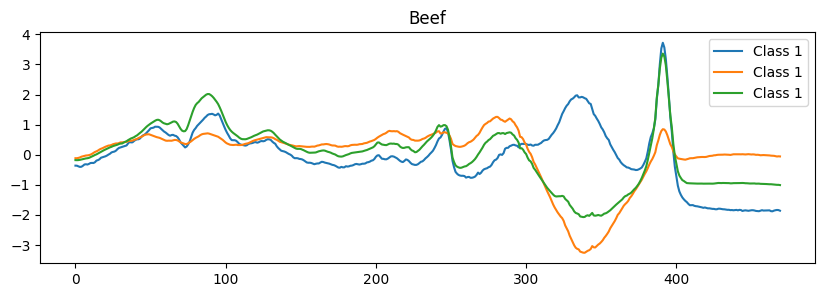

In [7]:
X_train_ts = X_train.transpose(0, 2, 1)
X_test_ts = X_test.transpose(0, 2, 1)

print(f"Train: {X_train_ts.shape}, Test: {X_test_ts.shape}")

plt.figure(figsize=(10, 3))
for i in range(3):
    plt.plot(X_train[i].squeeze(), label=f'Class {y_train[i]}')
plt.title('Beef')
plt.legend()
plt.show()

In [8]:
classification_results = {}

**Distance-based models**

In [17]:
from tslearn.neighbors import KNeighborsTimeSeriesClassifier
from sklearn.metrics import accuracy_score

metrics = ['euclidean', 'ctw', 'dtw']
for metric in metrics:
    model = KNeighborsTimeSeriesClassifier(n_neighbors=3, metric=metric).fit(X_train_ts, y_train)
    accuracy = accuracy_score(y_test, model.predict(X_test_ts))
    classification_results[f'KNeighborsTimeSeriesClassifier {metric}'] = accuracy
    print(f"KNeighborsTimeSeriesClassifier {metric}: {round(accuracy, 4)}")

KNeighborsTimeSeriesClassifier euclidean: 0.6
KNeighborsTimeSeriesClassifier ctw: 0.5667
KNeighborsTimeSeriesClassifier dtw: 0.5667


**Feature-based models**

In [9]:
from tsfresh import extract_features, select_features
from tsfresh.utilities.dataframe_functions import impute
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

def ts_to_dataframe(X, y=None):
    n_samples, n_timesteps, n_features = X.shape
    rows = []
    for i in range(n_samples):
        for t in range(n_timesteps):
            row = {'id': i, 'time': t}
            for f in range(n_features):
                row[f'feature_{f}'] = X[i, t, f]
            rows.append(row)
    df = pd.DataFrame(rows)
    if y is not None:
        y_df = pd.Series(y, name='target')
        return df, y_df
    return df

In [18]:
df, y_series = ts_to_dataframe(X_train, y_train)
features = extract_features(df, column_id="id", column_sort="time")
features = impute(features)

selected_features = select_features(features, y_series)
print(f"Отобрано признаков для классификации: {len(selected_features)}")

Feature Extraction: 100%|██████████| 14100/14100 [20:47<00:00, 11.30it/s]
/usr/local/lib/python3.13/dist-packages/tsfresh/utilities/dataframe_functions.py:198: RuntimeWarning: The columns ['feature_0__mean_abs_change' 'feature_0__mean_change'
 'feature_0__mean_second_derivative_central' ...
 'feature_469__permutation_entropy__dimension_7__tau_1'
 'feature_469__query_similarity_count__query_None__threshold_0.0'
 'feature_469__mean_n_absolute_max__number_of_maxima_7'] did not have any finite values. Filling with zeros.
  warnings.warn(


Отобрано признаков для классификации: 30


In [19]:
X_feat = features[selected_features.columns].values
X_feat_test = ts_to_dataframe(X_test)
features_test = extract_features(X_feat_test, column_id="id", column_sort="time")
features_test = impute(features_test)[selected_features.columns].values

Feature Extraction: 100%|██████████| 14100/14100 [20:48<00:00, 11.29it/s]
/usr/local/lib/python3.13/dist-packages/tsfresh/utilities/dataframe_functions.py:198: RuntimeWarning: The columns ['feature_0__mean_abs_change' 'feature_0__mean_change'
 'feature_0__mean_second_derivative_central' ...
 'feature_469__permutation_entropy__dimension_7__tau_1'
 'feature_469__query_similarity_count__query_None__threshold_0.0'
 'feature_469__mean_n_absolute_max__number_of_maxima_7'] did not have any finite values. Filling with zeros.
  warnings.warn(


In [20]:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_feat, y_train)
y_pred_rf = rf_clf.predict(features_test)
print(f"RandomForest accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")

svm_feat_clf = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_feat_clf.fit(X_feat, y_train)
y_pred_svm_feat = svm_feat_clf.predict(features_test)
print(f"SVM (kernel=rbf) accuracy: {accuracy_score(y_test, y_pred_svm_feat):.3f}")

knn_feat_clf = KNeighborsClassifier(n_neighbors=5)
knn_feat_clf.fit(X_feat, y_train)
y_pred_knn_feat = knn_feat_clf.predict(features_test)
print(f"KNN accuracy: {accuracy_score(y_test, y_pred_knn_feat):.3f}")

RandomForest accuracy: 0.700
SVM (kernel=rbf) accuracy: 0.533
KNN accuracy: 0.533


**Deep learning models**

In [22]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

from tslearn.neural_network import TimeSeriesMLPClassifier
activations = ['relu', 'logistic', 'tanh']
solvers = ['lbfgs', 'sgd', 'adam']

for activation, solver in zip(activations, solvers):
    model = TimeSeriesMLPClassifier(activation=activation, solver=solver).fit(X_train_ts, y_train)
    accuracy = accuracy_score(y_test, model.predict(X_test_ts))
    classification_results[f'TimeSeriesMLPClassifier with activation={activation}, solver={solver}'] = accuracy
    print(f"TimeSeriesMLPClassifier with activation={activation}, solver={solver}: {round(accuracy, 4)}")

TimeSeriesMLPClassifier with activation=relu, solver=lbfgs: 0.6333
TimeSeriesMLPClassifier with activation=logistic, solver=sgd: 0.4333
TimeSeriesMLPClassifier with activation=tanh, solver=adam: 0.8667
